In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [36]:
np.random.seed(0)
torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
# device = "mps" 

In [3]:
def expert_policy(x, y, alpha=0.25, noise_std=0.05, amax=0.5):
    dx = -alpha * x + np.random.randn() * noise_std
    dy = -alpha * y + np.random.randn() * noise_std

    dx = float(np.clip(dx, -amax, amax))
    dy = float(np.clip(dy, -amax, amax))

    return dx, dy

In [ ]:
def generate_xy_dataset_clipped(start_points, horizon=25, alpha=0.25, 
                                                noise_std=0.05, amax=0.5):
    """
    Returns:
        X: (N,2) states (x,y)
        Y: (N,2) actions (dx,dy)
    """
    states, actions = [], []

    for (x0, y0) in start_points:
        x, y = float(x0), float(y0)

        for _ in range(horizon):
            dx, dy = expert_policy(x, y, alpha, noise_std, amax)

            states.append([x, y])
            actions.append([dx, dy])

            x += dx
            y += dy

    return np.array(states, np.float32), np.array(actions, np.float32)

In [9]:
horizon = 25
alpha = 0.25
noise_std = 0.05
amax = 0.5  # ★ action clip
start_points = [(1.0,1.0), (2.0,2.0)]


In [10]:
X, Y = generate_xy_dataset_clipped(
    start_points=start_points,
    horizon=horizon,
    alpha=alpha,
    noise_std=noise_std,
    amax=amax
)
print("Dataset:", X.shape, Y.shape)

Dataset: (50, 2) (50, 2)


In [ ]:
def plot_expert_trajectories(X, Y, horizon=25, title="Expert demos (clipped)"):
    num_eps = len(X) // horizon
    idx = 0

    plt.figure(figsize=(5,5))
    for ep in range(num_eps):
        traj = [(X[idx,0], X[idx,1])]
        for _ in range(horizon):
            dx, dy = Y[idx]
            x, y = traj[-1]
            traj.append((x + dx, y + dy))
            idx += 1

        traj = np.array(traj)
        plt.plot(traj[:,0], traj[:,1], "-o", alpha=0.8, label=f"ep {ep}")

    plt.scatter(0, 0, c="red", s=120, marker="x", label="goal (0,0)")
    plt.axis("equal"); plt.grid(alpha=0.3); plt.legend(); plt.title(title); plt.show()

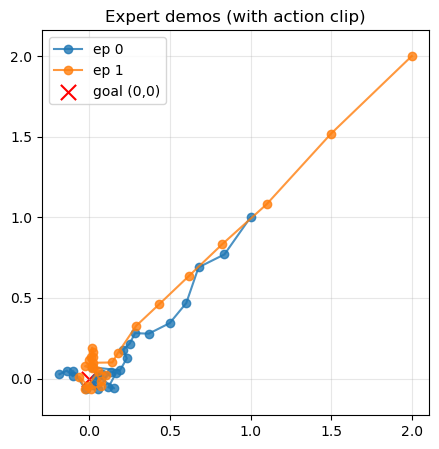

In [12]:
plot_expert_trajectories(X, Y, horizon=horizon, title="Expert demos (with action clip)")

In [13]:
class BCPolicy(nn.Module):
    def __init__(self, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, 2)
        )

    def forward(self, x):
        return self.net(x)

In [14]:
def train_bc(X, Y, epochs=800, lr=1e-3):
    model = BCPolicy(hidden=64).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    X_t = torch.from_numpy(X).to(device)
    Y_t = torch.from_numpy(Y).to(device)

    for ep in range(1, epochs + 1):
        model.train()
        pred = model(X_t)
        loss = F.mse_loss(pred, Y_t)

        opt.zero_grad()
        loss.backward()
        opt.step()

        if ep % 100 == 0 or ep == 1:
            print(f"[Epoch {ep:04d}] loss={loss.item():.6f}")

    return model

In [ ]:
@torch.no_grad()
def rollout_bc_clipped(policy, start, horizon=60, amax=0.5):
    x, y = float(start[0]), float(start[1])
    traj = [(x, y)]

    for _ in range(horizon):
        s = torch.tensor([[x, y]], dtype=torch.float32).to(device)
        dx, dy = policy(s).cpu().numpy()[0]

        # rollout clip
        dx = float(np.clip(dx, -amax, amax))
        dy = float(np.clip(dy, -amax, amax))

        x += dx
        y += dy
        traj.append((x, y))

    return np.array(traj, dtype=np.float32)

In [16]:
model = train_bc(X, Y, epochs=800, lr=1e-3)

[Epoch 0001] loss=0.013123
[Epoch 0100] loss=0.002521
[Epoch 0200] loss=0.002467
[Epoch 0300] loss=0.002438
[Epoch 0400] loss=0.002426
[Epoch 0500] loss=0.002401
[Epoch 0600] loss=0.002390
[Epoch 0700] loss=0.002383
[Epoch 0800] loss=0.002375


In [17]:
def plot_rollout(traj, start, title="BC rollout (clipped)"):
    plt.figure(figsize=(5,5))
    plt.plot(traj[:,0], traj[:,1], "-o", label="rollout")
    plt.scatter(start[0], start[1], c="green", s=80, label=f"start {start}")
    plt.scatter(0, 0, c="red", s=120, marker="x", label="goal (0,0)")
    plt.axis("equal")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.title(title)
    plt.show()

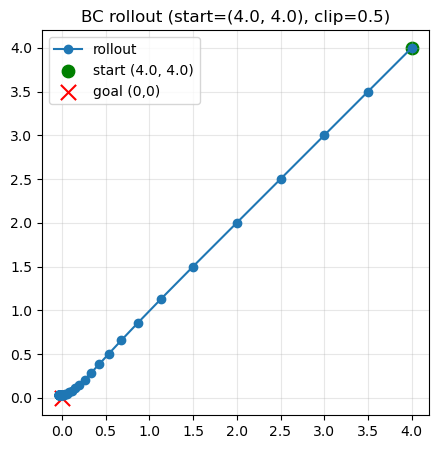

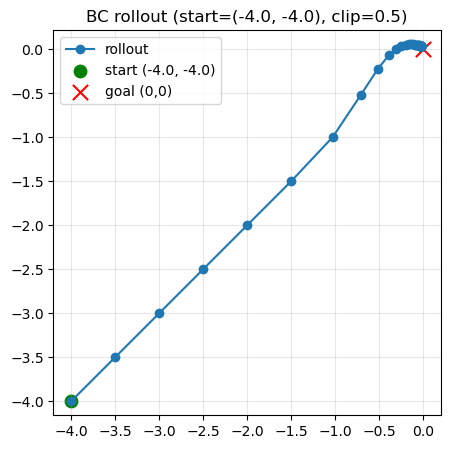

In [18]:
tests = [(4.0, 4.0), (-4.0, -4.0)]
for st in tests:
    traj = rollout_bc_clipped(model, st, horizon=80, amax=amax)
    plot_rollout(traj, st, title=f"BC rollout (start={st}, clip={amax})")